In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pandas as pd
import numpy as np
from torch.utils import data

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
train_data_path = "/media/cat/387cc6f2-632d-43da-98eb-59577e9d8634/paul/thesis_code/netho-seq-1/data/data-clean-all-split0.parquet"
train_data = pd.read_parquet(train_data_path)

print(train_data.shape)
train_data_subset = train_data.sample(n=10000, random_state=42)
print(train_data_subset.shape)

train_data_subset = train_data_subset.drop(columns=['sequenceId', 'subsequenceId', 'inputCol'])
train_data_subset = train_data_subset.to_numpy(dtype=np.float32)

(5519584, 94)
(10000, 94)


In [13]:
from VAE import VAE
from train import train
import torch.utils.data as data
from torch.utils.data import DataLoader
import numpy as np


X = torch.from_numpy(train_data_subset)
print(X.shape)
train_dataset = data.TensorDataset(X, X)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
n_epochs = 100
model = VAE(input_dim=X.shape[1], hidden_dim=128, latent_dim=32)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
loss_fn = nn.MSELoss()

losses = train(model, train_loader, optimizer, loss_fn, n_epochs, device)



torch.Size([10000, 91])
Epoch 0, Batch 0, Loss: 1.1659290790557861
Epoch 0, Batch 100, Loss: 0.7229502201080322
Epoch 1, Batch 0, Loss: 0.9680265188217163
Epoch 1, Batch 100, Loss: 0.8840944170951843
Epoch 2, Batch 0, Loss: 0.529717206954956
Epoch 2, Batch 100, Loss: 0.6006367206573486
Epoch 3, Batch 0, Loss: 0.8049747347831726
Epoch 3, Batch 100, Loss: 0.5097789764404297
Epoch 4, Batch 0, Loss: 0.6719852685928345
Epoch 4, Batch 100, Loss: 0.4508678913116455
Epoch 5, Batch 0, Loss: 0.5988544821739197
Epoch 5, Batch 100, Loss: 0.4374702572822571
Epoch 6, Batch 0, Loss: 0.49453413486480713
Epoch 6, Batch 100, Loss: 0.6337217688560486
Epoch 7, Batch 0, Loss: 0.6944775581359863
Epoch 7, Batch 100, Loss: 0.7427253723144531
Epoch 8, Batch 0, Loss: 0.5827308297157288
Epoch 8, Batch 100, Loss: 0.550582230091095
Epoch 9, Batch 0, Loss: 0.8026748895645142
Epoch 9, Batch 100, Loss: 1.3018925189971924
Epoch 10, Batch 0, Loss: 0.637467622756958
Epoch 10, Batch 100, Loss: 0.6446417570114136
Epoch 11

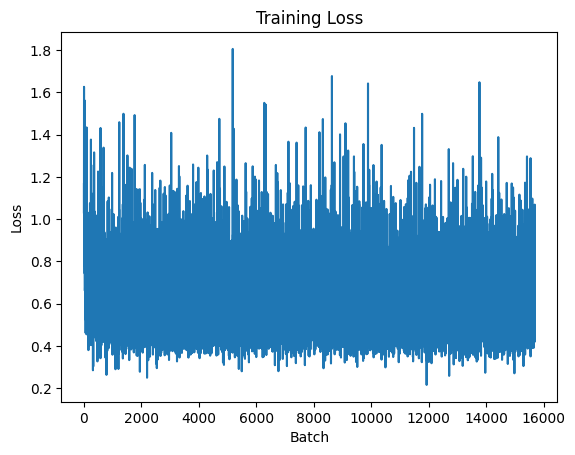

In [14]:
def plot_losses(losses):
    import matplotlib.pyplot as plt
    plt.plot(losses)
    plt.xlabel('Batch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.show()
plot_losses(losses)